### <span style="text-decoration: double underline; color:rgb(17, 129, 221)">**Resultados Finales Annealed DiffGoL** </span>

#### <span style="text-decoration: underline; color:rgb(17,129,221)">**1. Métricas durante el Train** </span>

Estas métricas son con respecto a la matriz de confusión, por lo que no están focalizadas a que estructuralmente coincidan.

In [1]:
import os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
os.environ['CUDA_VISIBLE_DEVICES'] = ""
import Auxiliares.Funciones.Results.func_evaluacion_init as evaluator_init
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pathlib import Path
import Auxiliares.Funciones.Boards.func_load_npz as loader
import Auxiliares.Funciones.Graficas.func_graficador as grapher
import Auxiliares.Funciones.Modelo.func_conway as conway
import Auxiliares.Clases.class_GoLayer as GoLayer

In [2]:
seeds = [221, 502, 700, 1204, 3340, 4501, 6054, 6621, 8421, 15678,  19302, 38475, 77293, 91827, 99100]
shape = (15,15)
path_datos =  './Resultados/Resultados_AnnDiffGoL'
path_datos = Path(path_datos)
path_historiales = []
path_test_results = []
path_predicciones = {}
path_reales = {}
for seed in seeds:
    path_historial= path_datos/f'Train/Historiales/history_{seed}.csv'
    path_test_result= path_datos/f'Test/Metricas/test_results_{seed}.csv'
    path_prediccion = path_datos/f'Test/Predicciones/predicciones_{seed}.csv'
    path_real = path_datos/f'Boards/Test/test_{seed}.npz'
    path_historiales.append(path_historial)
    path_test_results.append(path_test_result)
    path_predicciones[f'{seed}'] = path_prediccion
    path_reales[f'{seed}'] = path_real

Loss en train: 0.9979 ± 0.0032
Loss en val: 1.0052 ± 0.0047



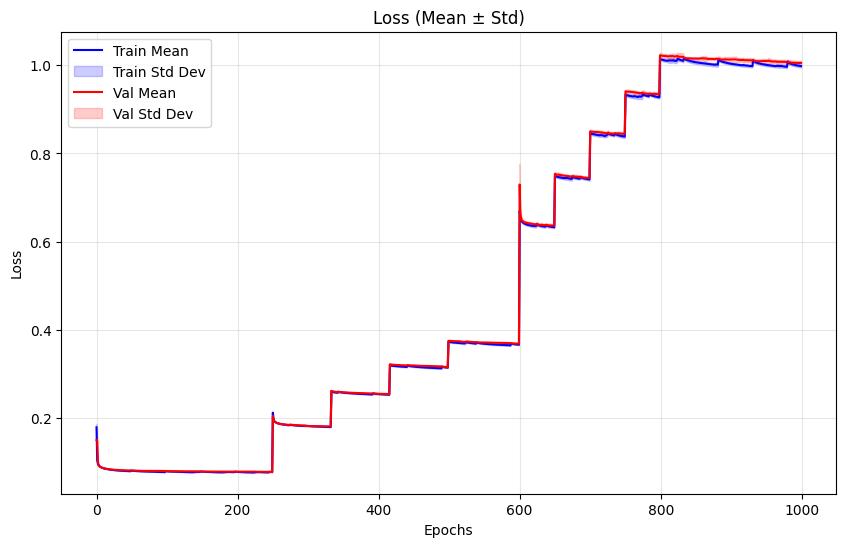

Accuracy en train (init): 0.8068 ± 0.0007
Accuracy en val (init): 0.8068 ± 0.0007

Recall en train (init): 0.4839 ± 0.0014
Recall en val (init): 0.4817 ± 0.0028

Precision en train (init): 0.5485 ± 0.0017
Precision en val (init): 0.5481 ± 0.0018

Specificity en train (init): 0.8933 ± 0.0008
Specificity en val (init): 0.8937 ± 0.0012

F1score en train (init): 0.5142 ± 0.0011
F1score en val (init): 0.5127 ± 0.0015

absolute en train (init): 0.0004 ± 0.0001
absolute en val (init): 0.0004 ± 0.0003



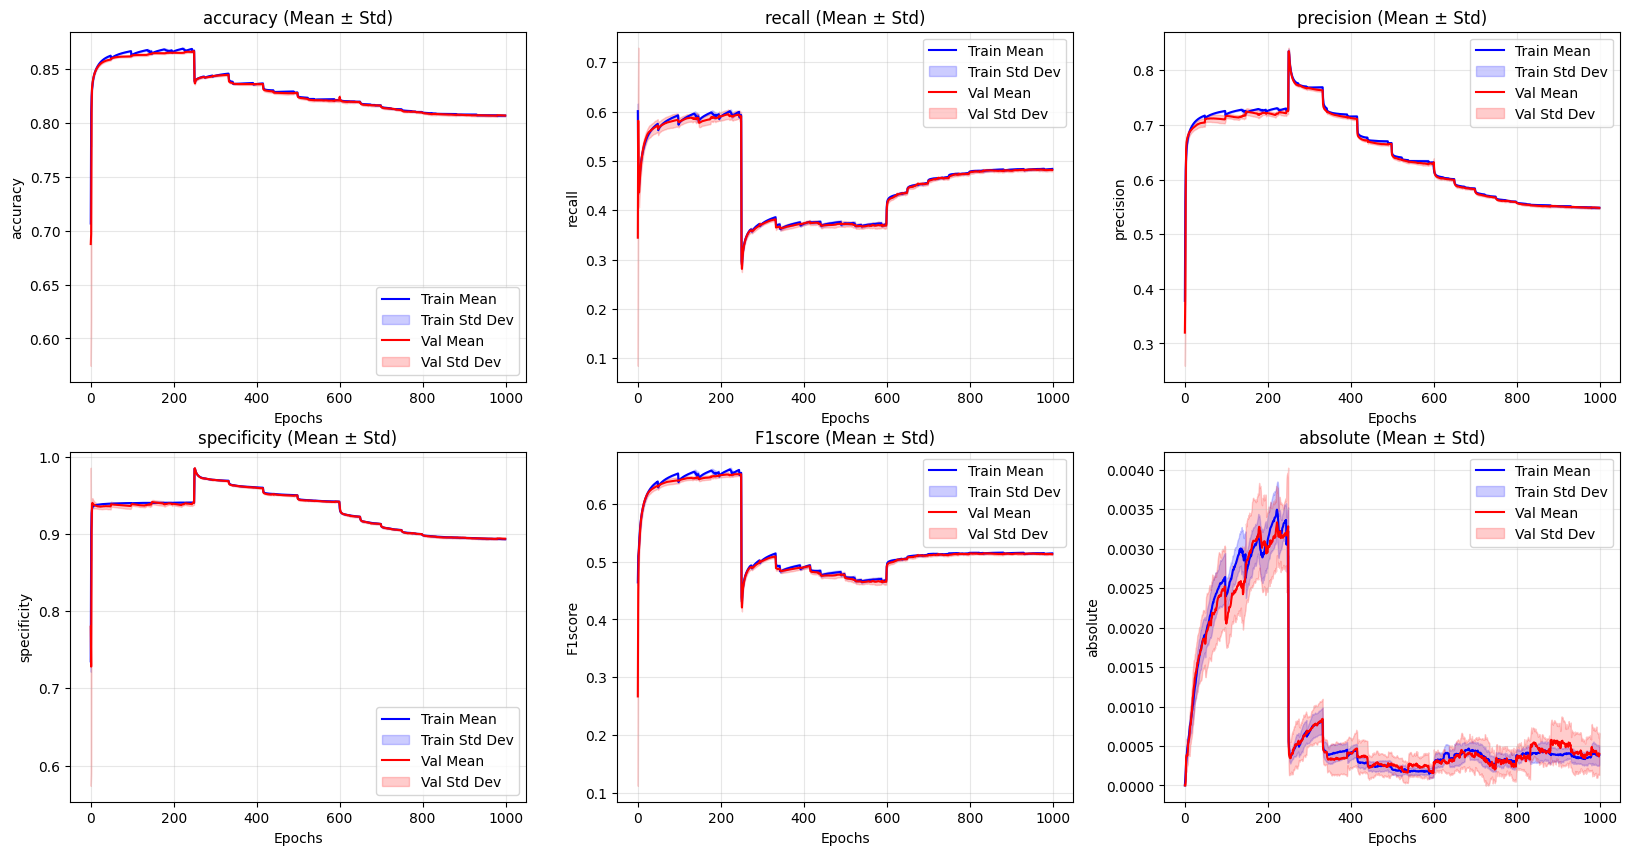

In [3]:
evaluator_init.loss_train_val(path_historiales)
evaluator_init.metrics_train_val(path_historiales,'init')

#### <span style="text-decoration: underline; color:rgb(17,129,221)">**2. Métricas en Test** </span>

In [4]:
headers = pd.read_csv(path_test_results[0]).columns.tolist()
evaluator_init.metrics_test(path_test_results, headers, headers)

F1score (iniciales): 0.5069 ± 0.0015
absolute (iniciales): 0.0003 ± 0.0002
acc_fin (finales): 0.8753 ± 0.0012
accuracy (iniciales): 0.7929 ± 0.0008
componenteBCE (finales): 0.2630 ± 0.0034
componenteBinarization (iniciales): 0.1281 ± 0.0011
componenteFBCE (finales): 0.3058 ± 0.0025
loss (iniciales): 1.0811 ± 0.0040
precision (iniciales): 0.5431 ± 0.0020
precision_fin (finales): 0.9282 ± 0.0024
recall (iniciales): 0.4753 ± 0.0025
recall_fin (finales): 0.4696 ± 0.0051
specificity (iniciales): 0.8846 ± 0.0013
specificity_fin (finales): 0.9898 ± 0.0003


#### <span style="text-decoration: underline; color:rgb(17,129,221)">**3. Plot de tableros** </span>

##### <span style="text-decoration: underline wavy; color:rgb(17,129,221)">**3.1. Comparativa** </span>

In [3]:
#  Headers de los csv:
stop_cols = [f"stop_{i}" for i in range(shape[0]*shape[1])]
init_cols = [f'start_{i}' for i in range(shape[0]*shape[1])]

# Datos para los plots:
umbral = 0.5
seed2plot = 1204

file_pred = path_predicciones[f'{seed2plot}']
file_test = path_datos/f'Boards/Test/test_{seed2plot}.npz'

    # Lectura de tableros predichos:
df_predicciones = pd.read_csv(file_pred, sep=',')

    # Preparación de tableros predichos:
# Tableros iniciales predichos:
init_prob = df_predicciones[init_cols].values  # (15_000, shape[0], shape[1])
init_bin = init_prob >umbral

# Tableros finales predichos:
finales_prob = df_predicciones[init_cols].values # (15_000, shape[0], shape[1])
finales_bin = finales_prob > umbral

# Tableros reales:

_ ,tab_iniciales, tab_finales = loader.load_npz(file_test, f'test_{seed2plot}.npz')

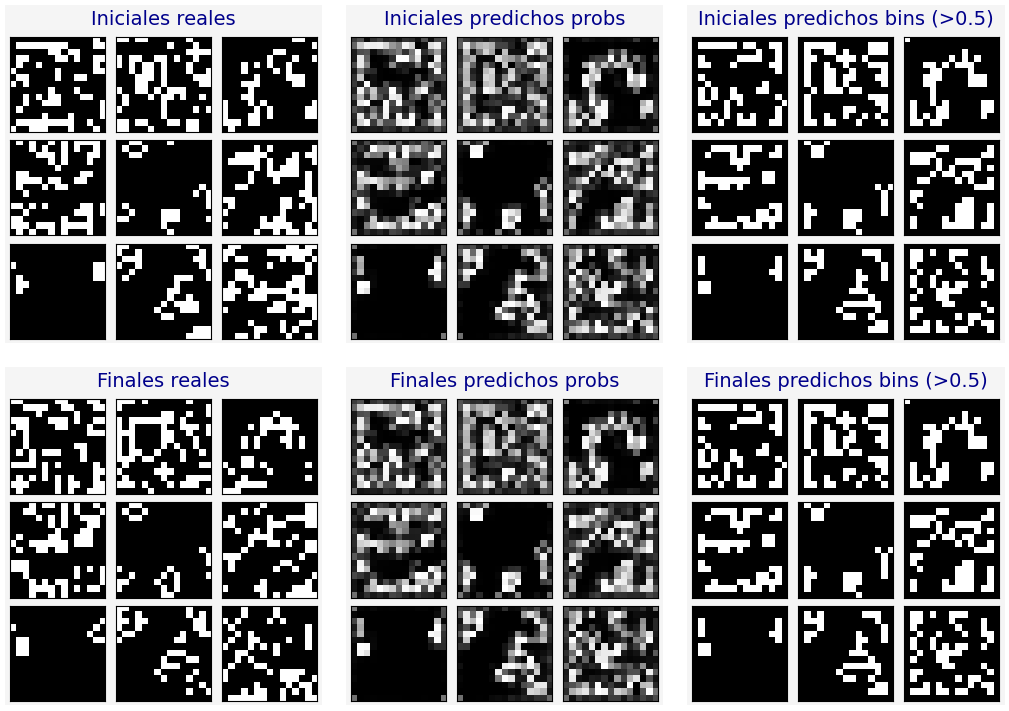

In [6]:
rows, cols = 3,3  # Número de tableros para ver
figsize = (10,7) # Ajustar el tamaño de la figura para que se vea bien.
random = False # Por si quereis ver tableros aleatorios (True o False)
tabs2plot = [tab_iniciales, init_prob, init_bin, tab_finales, finales_prob, finales_bin]
titles = ['Iniciales reales', 'Iniciales predichos probs', f'Iniciales predichos bins (>{umbral})', 
          'Finales reales', 'Finales predichos probs', f'Finales predichos bins (>{umbral})']

evaluator_init.multiplots(tabs2plot, titles, rows, cols, figsize, random)

##### <span style="text-decoration: underline wavy; color:rgb(17,129,221)">**3.2. Evolución** </span>

2026-02-20 09:06:16.573193: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


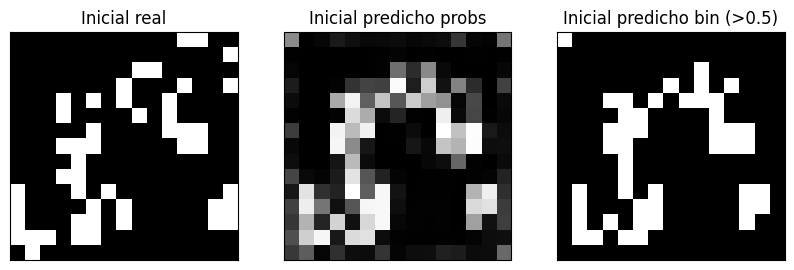

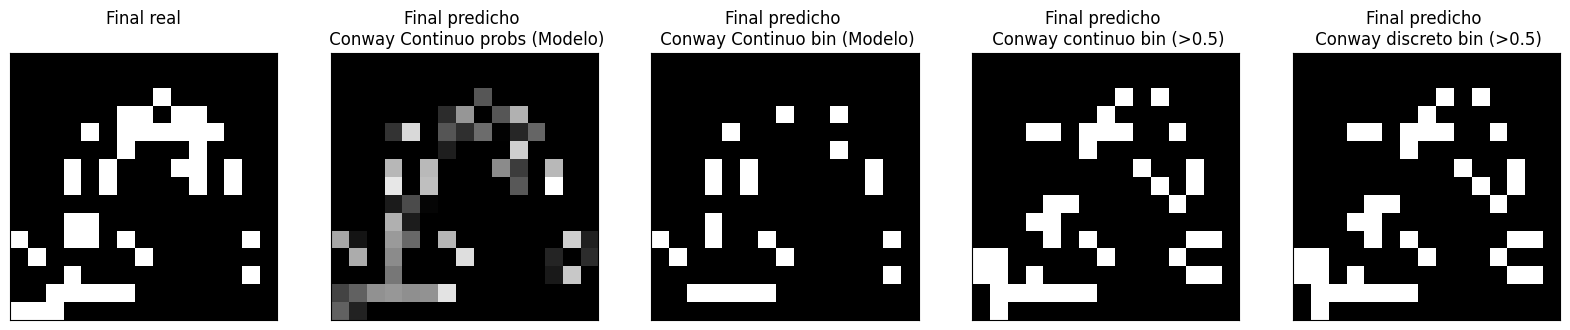

In [7]:
indice2plot = 2
# indice2plot = np.random.randint(0, len(tab_iniciales), 1) 

evaluator_init.evolution(indice2plot, init_bin, init_prob, tab_iniciales, tab_finales, umbral, (10,8), 'init')
evaluator_init.evolution(indice2plot, init_bin, init_prob, tab_iniciales, tab_finales, umbral, (20,10), 'final')

#### <span style="text-decoration: underline; color:rgb(17,129,221)">**4. Densidades** </span>

Densidad media predicha: 24.19%
Densidad media real: 22.36%
Desviación estándar pred: 8.87%
Desviación estándar real: 9.37%
Error en la densidad: 1.83%
Error en la std: 0.51%
Error medio por tablero: 10.60%
Células totales: 50625000
%HUC: 9.29% ± 0.18%
Porcentaje de células dudosas: 9.29% (4704716 células)
Valor máximo en las predicciones: 0.9999536


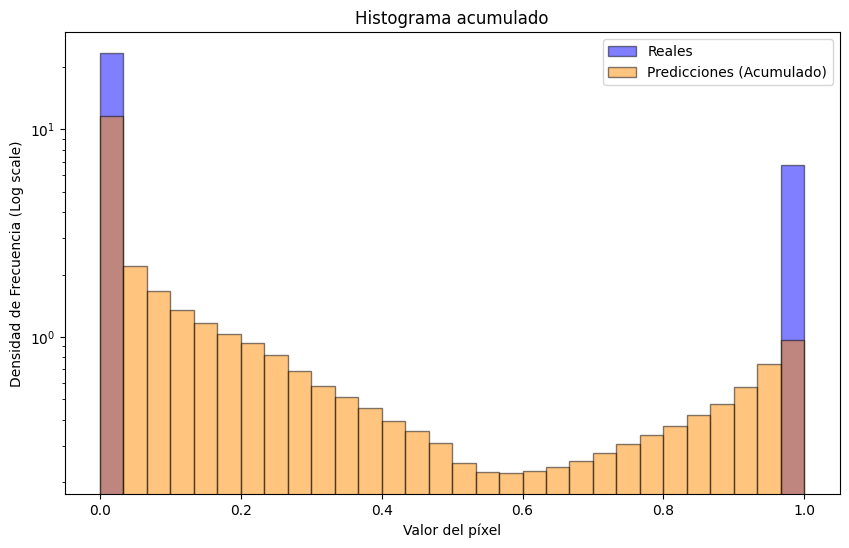

In [6]:
evaluator_init.density(path_predicciones, tab_iniciales, init_cols)
fig = evaluator_init.histograma(path_predicciones, tab_iniciales, init_cols, 0.35, 0.65)

#### <span style="text-decoration: underline; color:rgb(17,129,221)">**5. Wasserstein, Fuzziness Index, MSE y Sobolev sobre Iniciales** </span>

In [9]:
evaluator_init.compute_Wasserstein(path_predicciones, path_reales, init_cols)
evaluator_init.fuzzines_index(path_predicciones, init_cols)
evaluator_init.Sobolev(path_reales, path_predicciones, init_cols, shape, umbral, normalize=True)
evaluator_init.MSE(path_predicciones, path_reales, init_cols, umbral)

Wasserstein (EMD): 1.7453 ± 0.0073
Fuzziness Index: 0.3415 ± 0.0011
Sobolev medio modelo(prob): 2.6055 ± 0.0046 
Sobolev medio modelo(bin): 3.0490 ± 0.0053
Sobolev medio baseline OX: 3.0126
Sobolev medio baseline OY: 3.0119
Sobolev medio all zeros: 4.7037
Sobolev medio all ones: 12.0981
Sobolev medio si inversión: 10.7317
Sobolev medio si fuzzy boards: 5.3658
Diferencia Media en OX (bin): 0.0364
Diferencia Media en OY (bin): 0.0371
Diferencia Media en OX (prob): 0.4071
Diferencia Media en OY (prob): 0.4064
MSE Medio  (prob): 0.1540 ± 0.0005
MSE Medio (bin): 0.2071 ± 0.0007
MSE Medio allzeros: 0.2239 ± 0.0004


#### <span style="text-decoration: underline; color:rgb(17,129,221)">**6. Wasserstein, Fuzziness Index, MSE, Sobolev sobre Finales** </span>

In [10]:
import Auxiliares.Funciones.Results.func_evaluacion_fin as evaluator_fin

evaluator_fin.MSE(path_predicciones, path_reales, stop_cols, umbral, classic=False)
evaluator_fin.fuzziness_index(path_predicciones, stop_cols, classic=False)
evaluator_fin.compute_Wasserstein(path_predicciones, path_reales, stop_cols, classic=False)
evaluator_fin.Sobolev(path_reales, path_predicciones, stop_cols, shape, umbral, normalize=True, classic=False)

MSE Medio  (prob): 0.0836 ± 0.0008
MSE Medio (bin): 0.1247 ± 0.0011
MSE Medio allzeros: 0.2200 ± 0.0004
Fuzziness Index: 0.1933 ± 0.0006
Wasserstein (EMD): 1.9656 ± 0.0054
Sobolev medio modelo(prob): 2.5036 ± 0.0146 
Sobolev medio modelo(bin): 2.9388 ± 0.0187
Sobolev medio baseline OX: 2.9775
Sobolev medio baseline OY: 2.9781
Sobolev medio all zeros: 4.6483
Sobolev medio all ones: 12.1537
Sobolev medio si inversión: 10.8378
Sobolev medio si fuzzy boards: 5.4189
Diferencia Media en OX (bin): 0.0388
Diferencia Media en OY (bin): 0.0393
Diferencia Media en OX (prob): 0.4739
Diferencia Media en OY (prob): 0.4745
